In [ ]:
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import gc
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import random

import sys
sys.path.insert(0, '/glade/u/home/dcalhoun/censuswxindex')
from censuswxindex import aggregate as wxagg

## Demo: aggregate a few samples

In [ ]:
# Shapefile for aggregation
scratch = '/glade/derecho/scratch/dcalhoun'
shapefile_path = scratch + '/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'

In [ ]:
def build_fc_files(scratch, start, end, freq, lead_times):
    """Build list of forecast files (path, init_time, lead_time) for the given date range."""
    dates = pd.date_range(start=start, end=end, freq=freq)
    fc_files = []
    for init_time in dates:
        for lead_time in lead_times:
            date_str = init_time.strftime("%Y%m%d%H%M")
            year = date_str[:4]
            month = date_str[4:6]
            day = date_str[6:8]
            hour = date_str[8:]
            fc_path = glob.glob(scratch + f'/ecmwf/ifs/fc/0.125/2t/{hour}/{lead_time}/{year}/{month}/*{day}.nc')
            if fc_path:
                fc_files.append((fc_path[0], str(init_time), lead_time))
    return fc_files

In [ ]:
def build_an_files(scratch, start, end, freq):
    """Build list of analysis files (path, date) for the given date range."""
    dates = pd.date_range(start=start, end=end, freq=freq)
    an_files = []
    for date in dates:
        date_str = date.strftime("%Y%m%d")
        year = date_str[:4]
        month = date_str[4:6]
        an_path = glob.glob(scratch + f'/ecmwf/ifs/an/0.125/2t/{year}/{month}/*{date_str}.nc')
        if an_path:
            an_files.append((an_path[0], str(date)))
    return an_files

In [ ]:
# Build our lists of forecast and analysis files
start, end, freq = '2020-01-01', '2024-01-01', '12h'
lead_times = [12, 24, 36]
fc_files = build_fc_files(scratch, start=start, end=end, freq=freq, lead_times=lead_times)
an_files = build_an_files(scratch, start=start, end=end, freq=freq)
n_files = len(fc_files)
print(f'fc_files: {n_files}, an_files: {len(an_files)}')

fc_files: 5846, an_files: 2923


In [ ]:
# Pick random valid times and select aligned forecast + analysis
valid_from_fc = {pd.to_datetime(init) + pd.Timedelta(hours=lead): (path, init, lead) for path, init, lead in fc_files}
valid_from_an = {pd.to_datetime(t): (path, t) for path, t in an_files}
common_valid = sorted(set(valid_from_fc) & set(valid_from_an))
print("n_common: ", len(common_valid))
n_pick = min(4, len(common_valid))
picked_valid = sorted(random.sample(common_valid, n_pick))
fc_selected = [valid_from_fc[vt] for vt in picked_valid]
an_selected = [valid_from_an[vt] for vt in picked_valid]
for vt in picked_valid:
    fc_file = valid_from_fc[vt][0]
    an_file = valid_from_an[vt][0]
    fc_end = fc_file.split('/')[-1]
    an_end = an_file.split('/')[-1]
    print(f'{vt}: fc={fc_end} an={an_end}')

n_common:  2922
2021-03-27 00:00:00: fc=ifs_fc_2t_1200_12_20210326.nc an=ifs_an_2t_20210327.nc
2021-07-23 12:00:00: fc=ifs_fc_2t_0000_12_20210723.nc an=ifs_an_2t_20210723.nc
2023-10-04 12:00:00: fc=ifs_fc_2t_0000_12_20231004.nc an=ifs_an_2t_20231004.nc
2023-11-08 12:00:00: fc=ifs_fc_2t_0000_12_20231108.nc an=ifs_an_2t_20231108.nc


In [ ]:
# Define our GeoAggregator with our shapefile and grid
# Calculates a weightmap of overlaps between grid boxes and polygons
geo_agg = wxagg.GeoAggregator(shapefile_path=shapefile_path, grid_path=fc_selected[0][0])

In [ ]:
geo_agg

GeoAggregator
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * lat      (lat) float32 804B 24.5 24.62 24.75 24.88 ... 49.25 49.38 49.5
  * lon      (lon) float32 2kB -125.0 -124.9 -124.8 ... -66.75 -66.62 -66.5
CRS: 'WGS84'

In [ ]:
# Build our ForecastAggregator and AnalysisAggregator
# from our forecast and analysis files
# We use the weightmap we already calculated
fc_agg = wxagg.ForecastAggregator.from_GeoAggregator(geo_agg, forecast_files=fc_selected, var_name="t2m")
an_agg = wxagg.AnalysisAggregator.from_GeoAggregator(geo_agg, analysis_files=an_selected, var_name="t2m")

In [ ]:
fc_agg

ForecastAggregator
n_files: 4
init_times:
	2021-03-26 12:00:00
	2021-07-23 00:00:00
	2023-10-04 00:00:00
	2023-11-08 00:00:00
lead_times: [12]
var_name: 't2m'
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * lat      (lat) float32 804B 24.5 24.62 24.75 24.88 ... 49.25 49.38 49.5
  * lon      (lon) float32 2kB -125.0 -124.9 -124.8 ... -66.75 -66.62 -66.5
CRS: 'WGS84'

In [ ]:
an_agg

AnalysisAggregator
n_files: 4
times:
	2021-03-27 00:00:00
	2021-07-23 12:00:00
	2023-10-04 12:00:00
	2023-11-08 12:00:00
var_name: 't2m'
shapefile: '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023/US_county_2023.shp'
Coordinates:
  * lat      (lat) float32 804B 24.5 24.62 24.75 24.88 ... 49.25 49.38 49.5
  * lon      (lon) float32 2kB -125.0 -124.9 -124.8 ... -66.75 -66.62 -66.5
CRS: 'WGS84'

In [ ]:
# Run the aggregation to build a data table of our forecast data
df_fc = fc_agg.build_data_table()

In [ ]:
# Same for analysis
df_an = an_agg.build_data_table()

In [ ]:
df_fc

,geo_id,valid_time,init_time,lead_time,t2m
0,01001,2021-03-27 00:00:00,2021-03-26 12:00:00,12,293.737269
1,01003,2021-03-27 00:00:00,2021-03-26 12:00:00,12,295.579467
2,01005,2021-03-27 00:00:00,2021-03-26 12:00:00,12,295.053120
3,01007,2021-03-27 00:00:00,2021-03-26 12:00:00,12,293.275352
4,01009,2021-03-27 00:00:00,2021-03-26 12:00:00,12,292.725433
...,...,...,...,...,...
12431,56037,2023-11-08 12:00:00,2023-11-08 00:00:00,12,269.864020
12432,56039,2023-11-08 12:00:00,2023-11-08 00:00:00,12,266.612891
12433,56041,2023-11-08 12:00:00,2023-11-08 00:00:00,12,268.457826
12434,56043,2023-11-08 12:00:00,2023-11-08 00:00:00,12,271.786053


In [ ]:
df_an

,geo_id,time,t2m
0,01001,2021-03-27 00:00:00,296.708320
1,01003,2021-03-27 00:00:00,297.434981
2,01005,2021-03-27 00:00:00,297.324518
3,01007,2021-03-27 00:00:00,295.036081
4,01009,2021-03-27 00:00:00,295.010559
...,...,...,...
12431,56037,2023-11-08 12:00:00,271.052418
12432,56039,2023-11-08 12:00:00,267.316098
12433,56041,2023-11-08 12:00:00,269.454171
12434,56043,2023-11-08 12:00:00,272.136217


In [ ]:
# Save our aggregated features
fc_agg.save_data_table("test_fc.csv")
an_agg.save_data_table("test_an.csv")

In [ ]:
# Create table with bias (forecast - analysis) and abs_error
var = 't2m'
df_error = pd.merge(
    df_fc, df_an,
    left_on=['geo_id', 'valid_time'], right_on=['geo_id', 'time'],
    suffixes=('_fc', '_an'), how='inner'
)
df_error['bias'] = df_error[f'{var}_fc'] - df_error[f'{var}_an']
df_error['abs_error'] = df_error['bias'].abs()
df_error = df_error[['geo_id', 'valid_time', 'init_time', 'lead_time', f'{var}_fc', f'{var}_an', 'bias', 'abs_error']]
df_error

,geo_id,valid_time,init_time,lead_time,t2m_fc,t2m_an,bias,abs_error
0,01001,2021-03-27 00:00:00,2021-03-26 12:00:00,12,293.737269,296.708320,-2.971051,2.971051
1,01003,2021-03-27 00:00:00,2021-03-26 12:00:00,12,295.579467,297.434981,-1.855514,1.855514
2,01005,2021-03-27 00:00:00,2021-03-26 12:00:00,12,295.053120,297.324518,-2.271398,2.271398
3,01007,2021-03-27 00:00:00,2021-03-26 12:00:00,12,293.275352,295.036081,-1.760729,1.760729
4,01009,2021-03-27 00:00:00,2021-03-26 12:00:00,12,292.725433,295.010559,-2.285127,2.285127
...,...,...,...,...,...,...,...,...
12431,56037,2023-11-08 12:00:00,2023-11-08 00:00:00,12,269.864020,271.052418,-1.188398,1.188398
12432,56039,2023-11-08 12:00:00,2023-11-08 00:00:00,12,266.612891,267.316098,-0.703207,0.703207
12433,56041,2023-11-08 12:00:00,2023-11-08 00:00:00,12,268.457826,269.454171,-0.996345,0.996345
12434,56043,2023-11-08 12:00:00,2023-11-08 00:00:00,12,271.786053,272.136217,-0.350164,0.350164


In [ ]:
# Statistics by valid time
df_error.groupby('valid_time').bias.describe()

,count,mean,std,min,25%,50%,75%,max
valid_time,,,,,,,,
2021-03-27 00:00:00,3109.0,-1.496159,1.353201,-4.117599,-2.581180,-1.594465,-0.460618,3.127484
2021-07-23 12:00:00,3109.0,0.371669,0.940094,-1.989433,-0.227566,0.169602,0.800671,5.116240
2023-10-04 12:00:00,3109.0,0.403247,0.910417,-2.757367,-0.208809,0.402361,0.968359,3.374382
2023-11-08 12:00:00,3109.0,0.395884,1.079916,-2.501363,-0.395746,0.200254,1.214538,3.458654


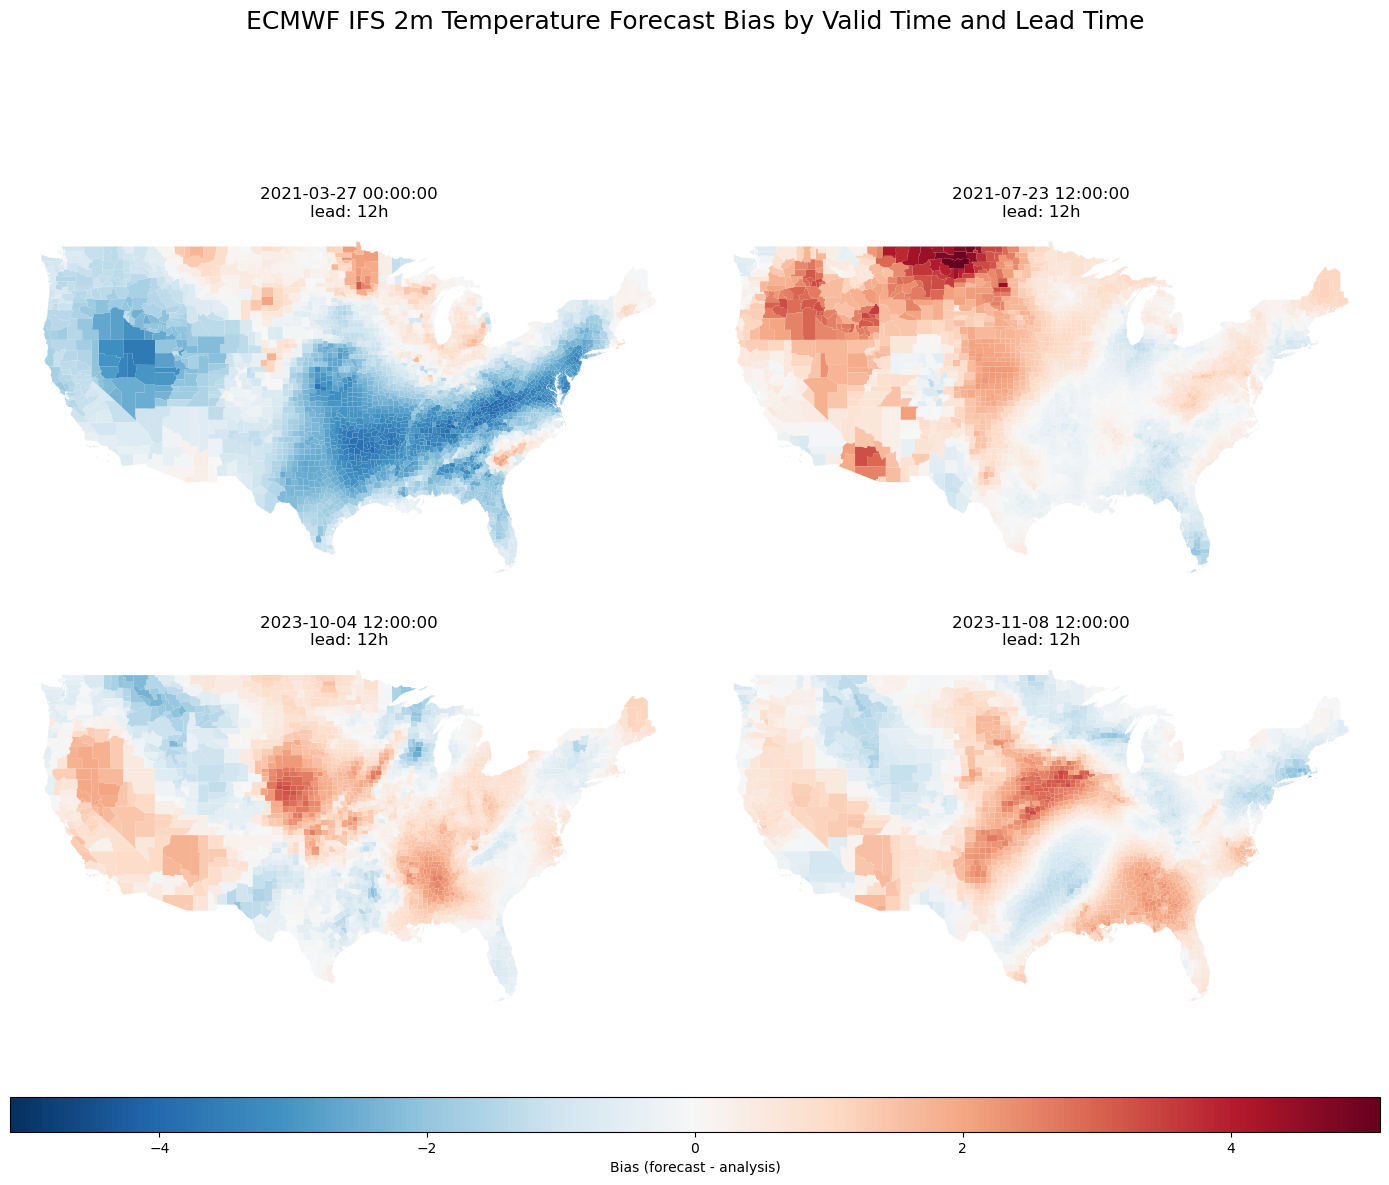

9

In [ ]:
# Plot bias maps by valid time
fc_agg.shapefile.rename(columns={'GEOID': 'geo_id'}, inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

bias_max = np.abs(df_error['bias']).max()
vmin, vmax = -bias_max, bias_max
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = 'RdBu_r'

valid_times = sorted(df_error['valid_time'].unique())
for ax, valid_time in zip(axes, valid_times):
    sub = df_error[df_error['valid_time'] == valid_time]
    gdf_plot = fc_agg.shapefile.merge(sub[['geo_id', 'bias']], on='geo_id', how='inner')
    gdf_plot.plot(ax=ax, column='bias', cmap=cmap, norm=norm)
    lead_val = sub['lead_time'].iloc[0]
    ax.set_title(f'{valid_time}\nlead: {lead_val}h')
    ax.set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.suptitle(
    'ECMWF IFS 2m Temperature Forecast Bias by Valid Time and Lead Time', 
    fontsize=18, 
    y=0.90  # Move title closer to panels
)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])  # Adjust for space at bottom for colorbar and a bit at top for title

fig.colorbar(
    sm,
    ax=axes.tolist(),
    orientation='horizontal',
    fraction=0.04,
    pad=0.07,
    aspect=40,
    label='Bias (forecast - analysis)'
)
plt.show()
plt.close(fig)
del gdf_plot; gc.collect()

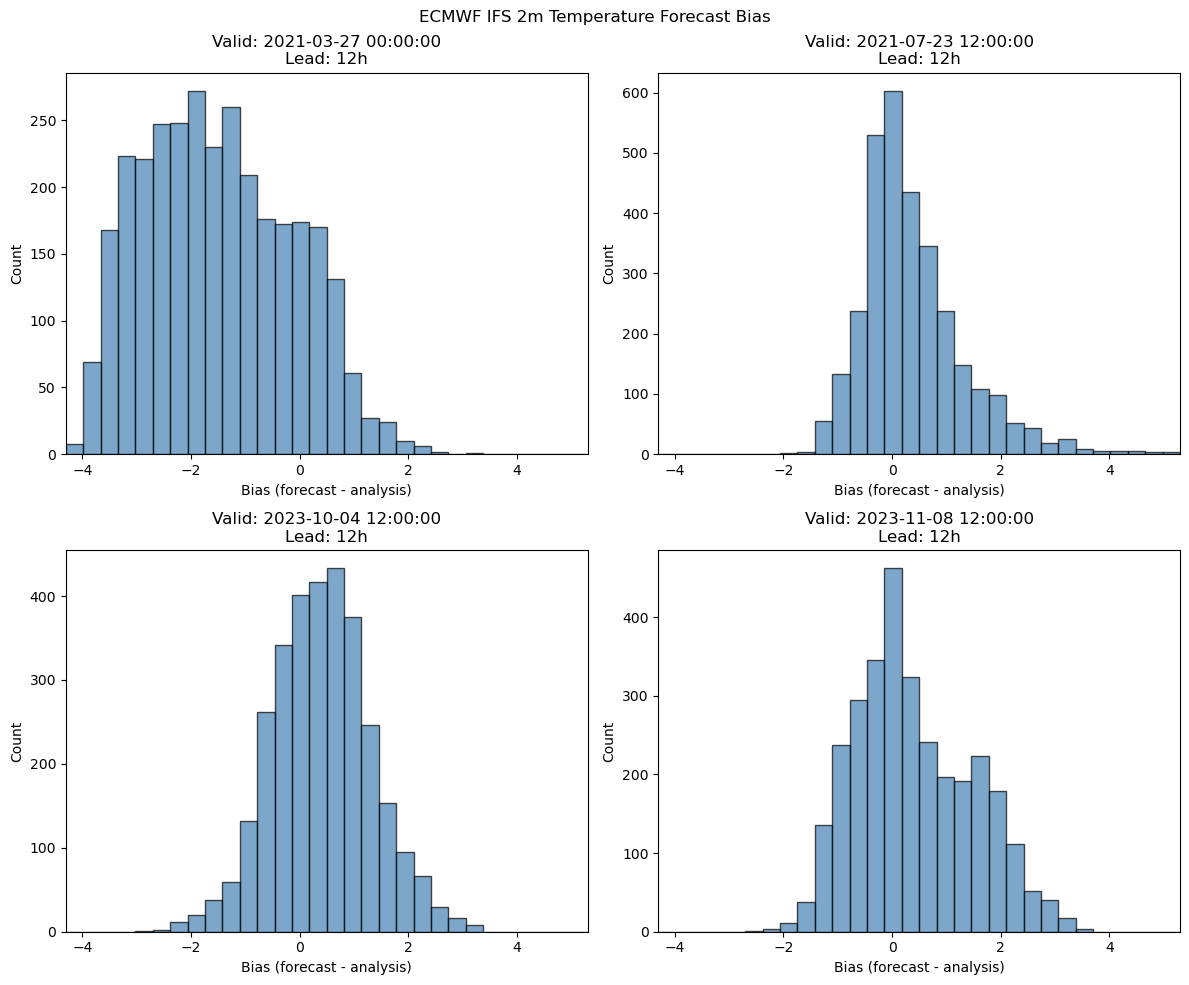

In [ ]:
# Plot forecast bias histograms by valid time
valid_times = sorted(df_error['valid_time'].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
bins = 30

bias_min = df_error['bias'].min()
bias_max = df_error['bias'].max()
padding = 0.02 * (bias_max - bias_min) if bias_max != bias_min else 0.1
bmin_pad = bias_min - padding
bmax_pad = bias_max + padding

bin_edges = np.linspace(bmin_pad, bmax_pad, bins + 1)

for ax, vt in zip(axes, valid_times):
    sub = df_error[df_error['valid_time'] == vt]
    ax.hist(sub['bias'], bins=bin_edges, color='steelblue', edgecolor='k', alpha=0.7)
    ax.set_title(f'Valid: {vt}\nLead: {sub["lead_time"].iloc[0]}h')
    ax.set_xlabel('Bias (forecast - analysis)')
    ax.set_ylabel('Count')
    ax.set_xlim([bmin_pad, bmax_pad])

plt.suptitle('ECMWF IFS 2m Temperature Forecast Bias')
plt.tight_layout()
plt.show()

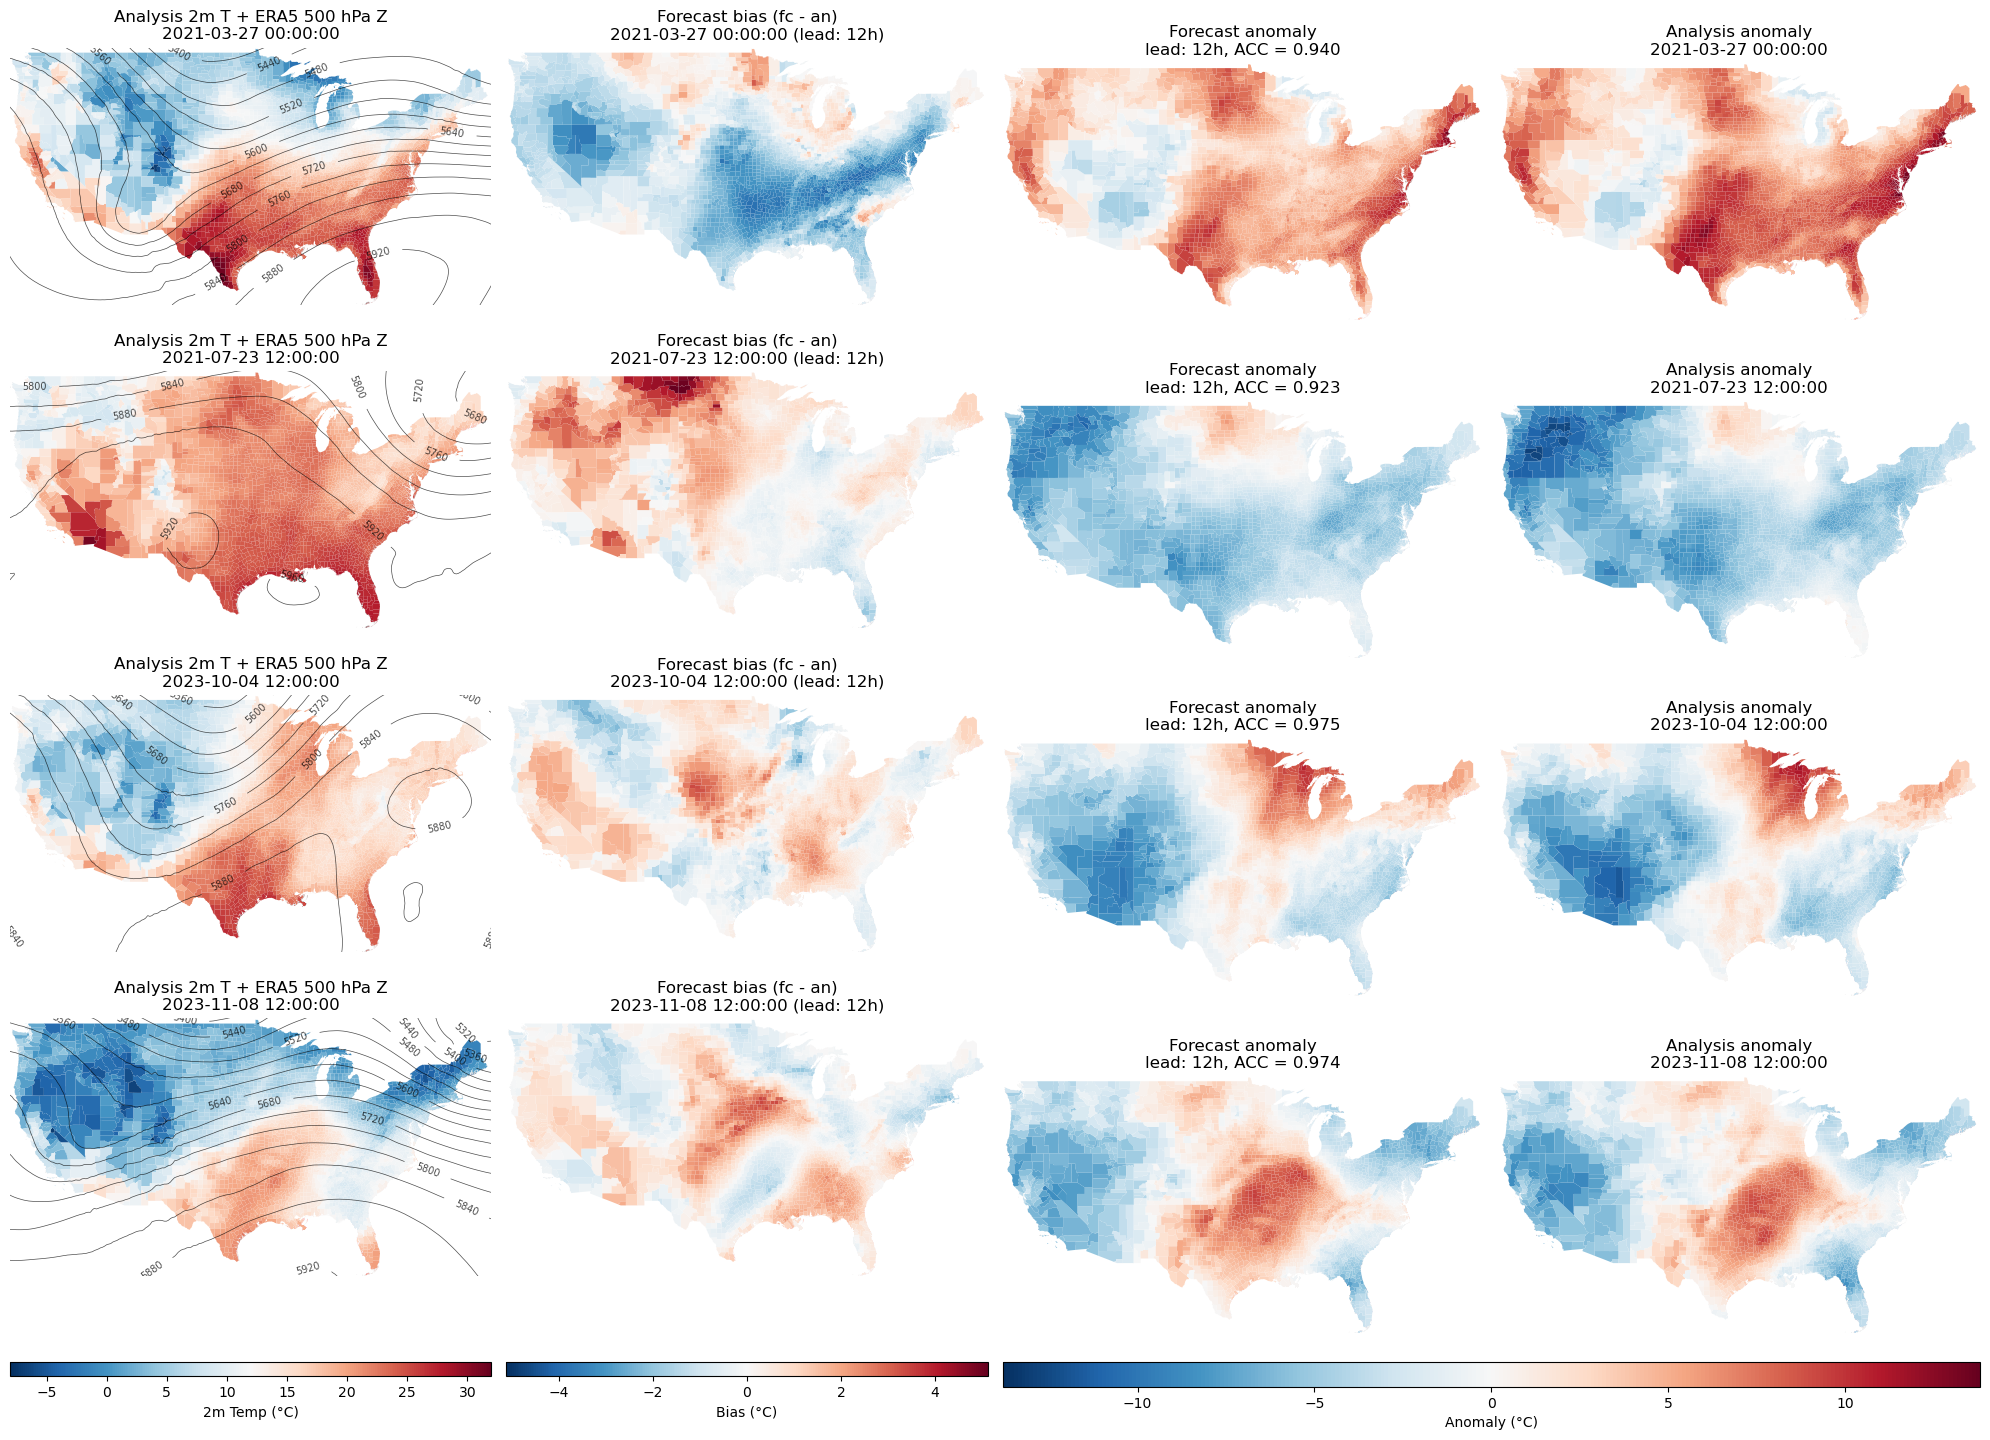

9

In [ ]:
# Forecast and analysis anomalies (relative to ERA5 climatology), with area-weighted ACC in title
scratch = '/glade/derecho/scratch/dcalhoun'
clim_path = scratch + '/ecmwf/era5/era5_2t_county_climatology_1991_2020.parquet'
clim = pd.read_parquet(clim_path)

df_error['day_of_year'] = pd.to_datetime(df_error['valid_time']).dt.dayofyear
df_a = df_error.merge(clim[['geo_id', 'day_of_year', 't2m_clim']], on=['geo_id', 'day_of_year'], how='inner')
df_a['t2m_fc_C'] = df_a['t2m_fc'] - 273.15
df_a['t2m_an_C'] = df_a['t2m_an'] - 273.15
df_a['t2m_clim_C'] = df_a['t2m_clim'] - 273.15
df_a['fc_anom'] = df_a['t2m_fc_C'] - df_a['t2m_clim_C']
df_a['an_anom'] = df_a['t2m_an_C'] - df_a['t2m_clim_C']
df_a['bias_C'] = df_a['t2m_fc_C'] - df_a['t2m_an_C']

# Use area column and coords from geo_agg.shapefile (already in geo_agg.coords)
# NHGIS county shapefile has ALAND (land area, m²); fallback to Shape_Area or 'area' if present
shp = geo_agg.shapefile.copy()
if 'GEOID' in shp.columns:
    shp = shp.rename(columns={'GEOID': 'geo_id'})
area_col = 'ALAND' if 'ALAND' in shp.columns else ('Shape_Area' if 'Shape_Area' in shp.columns else 'area')
area_by_geo = shp[['geo_id', area_col]].rename(columns={area_col: 'area_wt'})
df_a = df_a.merge(area_by_geo, on='geo_id', how='inner')

def weighted_acc(x, y, w):
    w = np.asarray(w, dtype=float)
    x, y = np.asarray(x), np.asarray(y)
    w = w / w.sum()
    m_x, m_y = (w * x).sum(), (w * y).sum()
    cov = (w * (x - m_x) * (y - m_y)).sum()
    std_x = np.sqrt((w * (x - m_x)**2).sum())
    std_y = np.sqrt((w * (y - m_y)**2).sum())
    if std_x == 0 or std_y == 0:
        return np.nan
    return cov / (std_x * std_y)

valid_times = sorted(df_a['valid_time'].unique())
acc_by_time = {}
for vt in valid_times:
    sub = df_a[df_a['valid_time'] == vt]
    acc_by_time[vt] = weighted_acc(sub['fc_anom'].values, sub['an_anom'].values, sub['area_wt'].values)

# ERA5 500 hPa for contour overlay (same date as valid_time)
ERA_PL_DIR = '/glade/campaign/collections/rda/data/d633000/e5.oper.an.pl'

def get_z500_for_day(date):
    """Load daily mean 500 hPa geopotential height (m) for date. Returns LON, LAT, z500_m or None."""
    dt = pd.Timestamp(date)
    month = dt.strftime('%Y%m')
    day = dt.strftime('%Y%m%d')
    pattern = f'{ERA_PL_DIR}/{month}/*128_129_z*{day}00_{day}23*.nc'
    files = glob.glob(pattern)
    if not files:
        return None
    with xr.open_dataset(files[0]) as ds:
        z = ds['Z'].sel(level=500).mean(dim='time')
        lon = np.array(ds['longitude'].values)
        lat = np.array(ds['latitude'].values)
        z_m = z.values / 9.80665
        idx = np.searchsorted(lon, 180)
        lon_180 = np.concatenate([lon[idx:] - 360, lon[:idx]])
        z_rolled = np.concatenate([z_m[:, idx:], z_m[:, :idx]], axis=1)
        mask_lon = (lon_180 >= -130) & (lon_180 <= -65)
        mask_lat = (lat >= 24) & (lat <= 50)
        lon_c = lon_180[mask_lon]
        lat_c = lat[mask_lat]
        z500_m = z_rolled[mask_lat, :][:, mask_lon]
        LON, LAT = np.meshgrid(lon_c, lat_c)
    return LON, LAT, z500_m

# Plot: one row per date; [Analysis+ERA5 Z500, Forecast bias, Forecast anomaly, Analysis anomaly]
lon = geo_agg.grid['lon'].values
lat = geo_agg.grid['lat'].values
xlim = (lon.min(), lon.max())
ylim = (lat.min(), lat.max())

anom_max = np.abs(df_a[['fc_anom', 'an_anom']]).max().max()
vmin_anom, vmax_anom = -anom_max, anom_max
norm_anom = Normalize(vmin=vmin_anom, vmax=vmax_anom)
cmap_anom = 'RdBu_r'

bias_max = np.abs(df_a['bias_C']).max()
norm_bias = Normalize(vmin=-bias_max, vmax=bias_max)
cmap_bias = 'RdBu_r'

vmin_T = df_a['t2m_an_C'].min()
vmax_T = df_a['t2m_an_C'].max()
norm_T = Normalize(vmin=vmin_T, vmax=vmax_T)
cmap_T = 'RdBu_r'

fig, axes = plt.subplots(len(valid_times), 4, figsize=(20, 4 * len(valid_times)))
if len(valid_times) == 1:
    axes = axes[np.newaxis, :]
for i, valid_time in enumerate(valid_times):
    sub = df_a[df_a['valid_time'] == valid_time]
    acc = acc_by_time[valid_time]
    lead_val = sub['lead_time'].iloc[0]
    gdf_plot = shp.merge(sub[['geo_id', 'fc_anom', 'an_anom', 't2m_an_C', 'bias_C']], on='geo_id', how='inner')
    gdf_plot = gdf_plot.to_crs(geo_agg.coords)
    # Col 0: Analysis 2m T + ERA5 z500 contours
    gdf_plot.plot(ax=axes[i, 0], column='t2m_an_C', cmap=cmap_T, norm=norm_T)
    axes[i, 0].set_xlim(xlim)
    axes[i, 0].set_ylim(ylim)
    axes[i, 0].set_title(f'Analysis 2m T + ERA5 500 hPa Z\n{valid_time}')
    axes[i, 0].set_axis_off()
    z500 = get_z500_for_day(valid_time)
    if z500 is not None:
        LON, LAT, z_m = z500
        levels = np.arange(5000, 6000, 40)
        cs = axes[i, 0].contour(LON, LAT, z_m, levels=levels, colors='k', linewidths=0.5, alpha=0.7)
        axes[i, 0].clabel(cs, inline=True, fontsize=7, fmt='%d')
    # Col 1: Forecast bias
    gdf_plot.plot(ax=axes[i, 1], column='bias_C', cmap=cmap_bias, norm=norm_bias)
    axes[i, 1].set_xlim(xlim)
    axes[i, 1].set_ylim(ylim)
    axes[i, 1].set_title(f'Forecast bias (fc - an)\n{valid_time} (lead: {lead_val}h)')
    axes[i, 1].set_axis_off()
    # Col 2: Forecast anomaly
    gdf_plot.plot(ax=axes[i, 2], column='fc_anom', cmap=cmap_anom, norm=norm_anom)
    axes[i, 2].set_xlim(xlim)
    axes[i, 2].set_ylim(ylim)
    axes[i, 2].set_title(f'Forecast anomaly\nlead: {lead_val}h, ACC = {acc:.3f}')
    axes[i, 2].set_axis_off()
    # Col 3: Analysis anomaly
    gdf_plot.plot(ax=axes[i, 3], column='an_anom', cmap=cmap_anom, norm=norm_anom)
    axes[i, 3].set_xlim(xlim)
    axes[i, 3].set_ylim(ylim)
    axes[i, 3].set_title(f'Analysis anomaly\n{valid_time}')
    axes[i, 3].set_axis_off()
sm_anom = plt.cm.ScalarMappable(cmap=cmap_anom, norm=norm_anom)
sm_anom.set_array([])
sm_bias = plt.cm.ScalarMappable(cmap=cmap_bias, norm=norm_bias)
sm_bias.set_array([])
sm_T = plt.cm.ScalarMappable(cmap=cmap_T, norm=norm_T)
sm_T.set_array([])
plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.colorbar(sm_T, ax=axes[:, 0].tolist(), orientation='horizontal', fraction=0.02, pad=0.06, aspect=35, label='2m Temp (°C)')
fig.colorbar(sm_bias, ax=axes[:, 1].tolist(), orientation='horizontal', fraction=0.02, pad=0.06, aspect=35, label='Bias (°C)')
fig.colorbar(sm_anom, ax=axes[:, 2:4].ravel().tolist(), orientation='horizontal', fraction=0.02, pad=0.02, aspect=40, label='Anomaly (°C)')
plt.show()
plt.close(fig)
del df_a, shp, clim, gdf_plot; gc.collect()

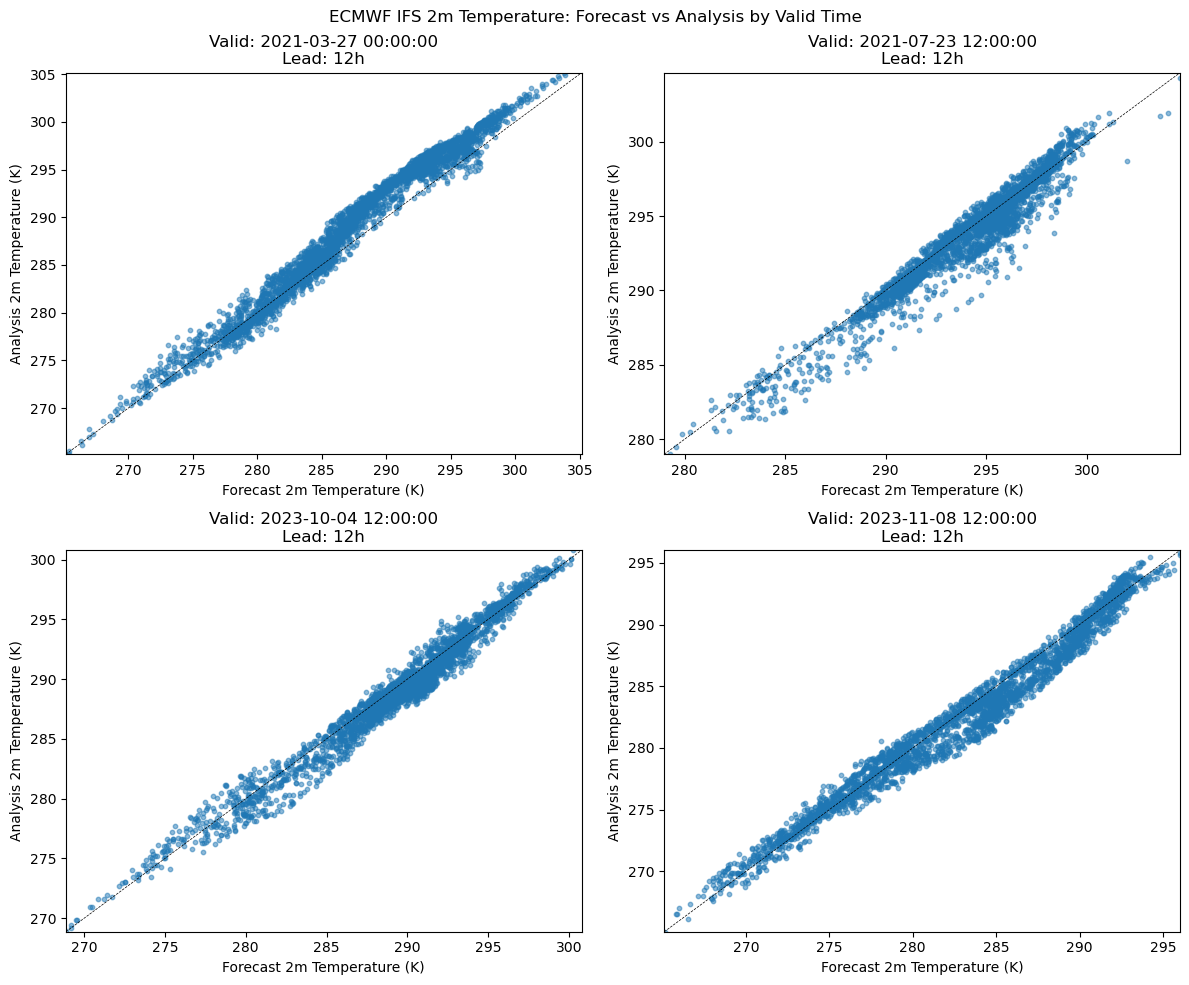

In [ ]:
# Scatter plot: forecast vs analysis temperature by valid time
valid_times = sorted(df_error['valid_time'].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, vt in zip(axes, valid_times):
    sub = df_error[df_error['valid_time'] == vt]
    ax.scatter(sub['t2m_fc'], sub['t2m_an'], alpha=0.5, s=10)
    lims = [sub[['t2m_fc', 't2m_an']].min().min(), sub[['t2m_fc', 't2m_an']].max().max()]
    ax.plot(lims, lims, 'k--', linewidth=0.5, label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Forecast 2m Temperature (K)')
    ax.set_ylabel('Analysis 2m Temperature (K)')
    ax.set_title(f'Valid: {vt}\nLead: {sub["lead_time"].iloc[0]}h')

plt.suptitle('ECMWF IFS 2m Temperature: Forecast vs Analysis by Valid Time')
plt.tight_layout()
plt.show()
plt.close(fig)

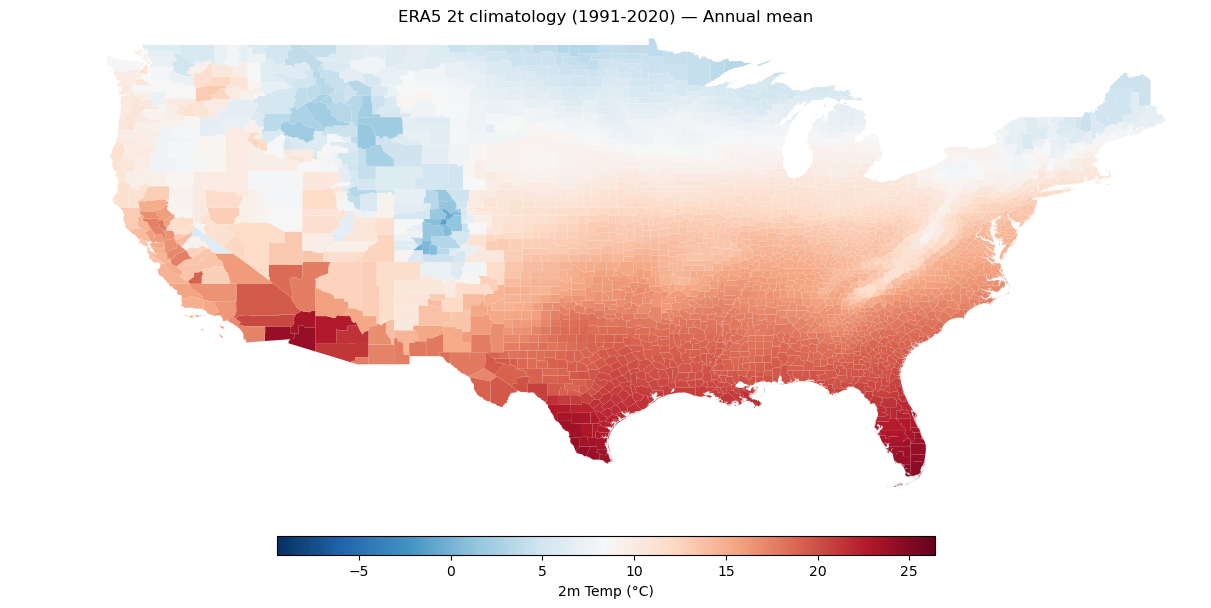

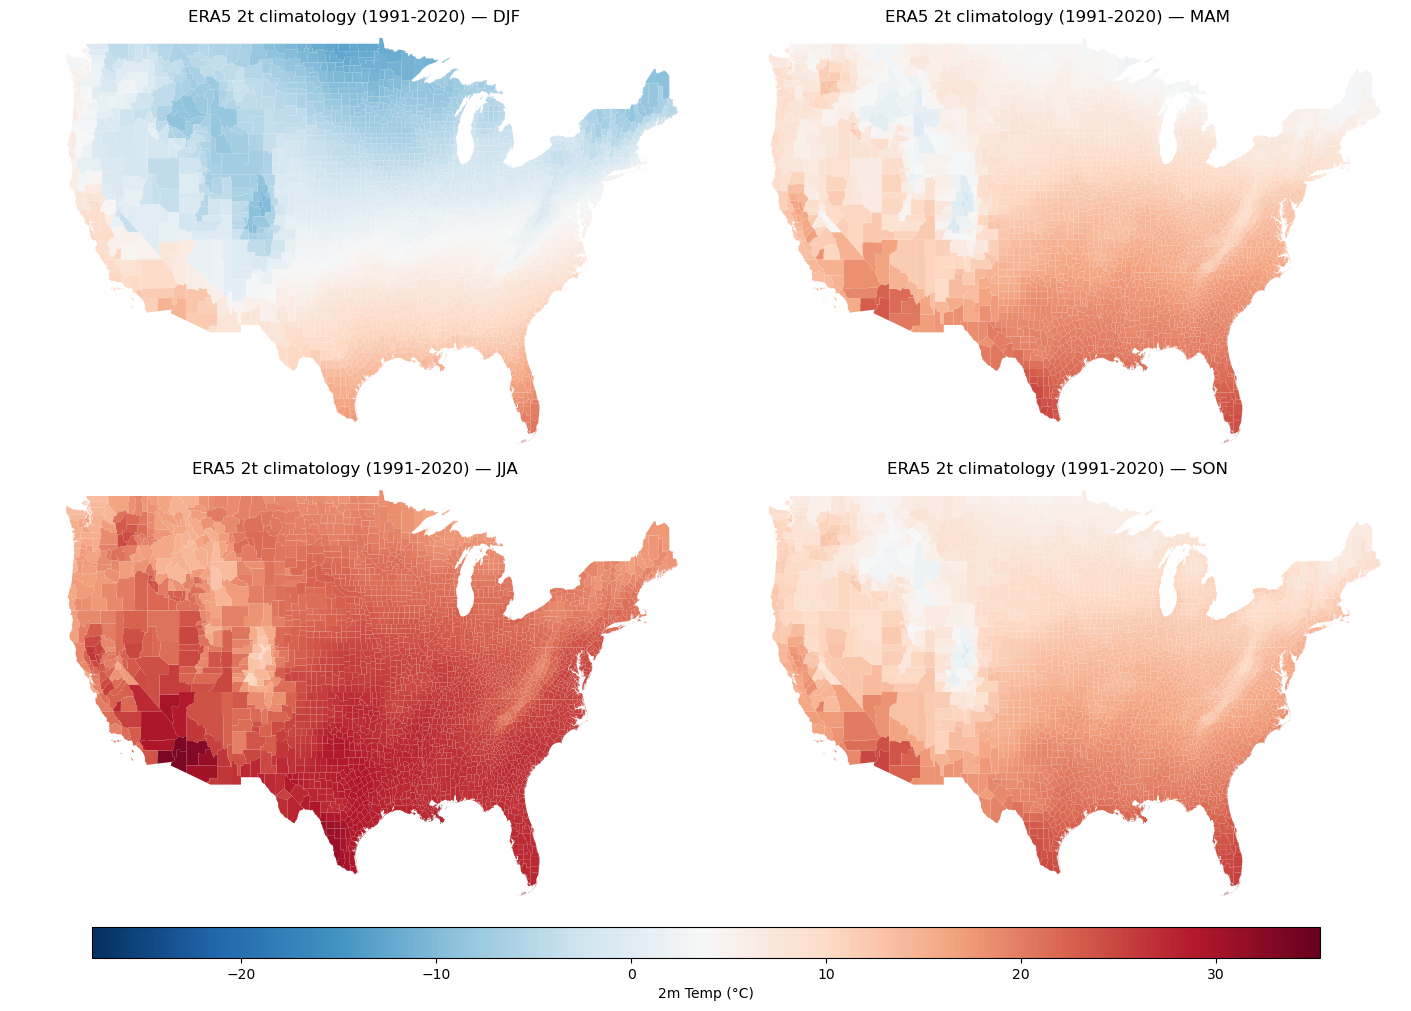

18

In [ ]:
# Load ERA5 county climatology and plot in normal (CONUS) view
# Climatology: per county, per day-of-year mean 2t (1991-2020)
# Annual mean and seasonal (DJF, MAM, JJA, SON) means — two separate figures
# Day-of-year ranges (non-leap): Dec=335-365, Jan=1-31, Feb=32-59, ...
doy_djf = list(range(1, 60)) + list(range(335, 366))
doy_mam = list(range(60, 152))
doy_jja = list(range(152, 244))
doy_son = list(range(244, 335))

scratch = '/glade/derecho/scratch/dcalhoun'
clim_path = scratch + '/ecmwf/era5/era5_2t_county_climatology_1991_2020.parquet'
clim = pd.read_parquet(clim_path)
clim['t2m_clim_C'] = clim['t2m_clim'] - 273.15

annual = clim.groupby('geo_id')['t2m_clim_C'].mean().reset_index()
annual.columns = ['geo_id', 't2m_C']
seasonal = {}
for name, doy_list in [('DJF', doy_djf), ('MAM', doy_mam), ('JJA', doy_jja), ('SON', doy_son)]:
    seasonal[name] = clim[clim['day_of_year'].isin(doy_list)].groupby('geo_id')['t2m_clim_C'].mean().reset_index()
    seasonal[name].columns = ['geo_id', 't2m_C']

gdf = gpd.read_file(shapefile_path).to_crs("WGS84")

# ----- Figure 1: Annual mean only, with its own colorbar -----
fig1, ax1 = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
vmin_a = annual['t2m_C'].min()
vmax_a = annual['t2m_C'].max()
merged_a = gdf.merge(annual, left_on='GEOID', right_on='geo_id', how='inner')
merged_a.plot(ax=ax1, column='t2m_C', cmap='RdBu_r', vmin=vmin_a, vmax=vmax_a, legend=False)
ax1.set_xlim(-130, -65)
ax1.set_ylim(24, 50)
ax1.set_aspect('auto')
ax1.set_title("ERA5 2t climatology (1991-2020) — Annual mean", pad=4)
ax1.set_axis_off()
fig1.colorbar(
    plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=vmin_a, vmax=vmax_a)),
    ax=ax1, orientation='horizontal', fraction=0.04, pad=0.08, aspect=35, label='2m Temp (°C)'
)
plt.show()
plt.close(fig1)

# ----- Figure 2: Four seasons with shared colorbar -----
vmin_s = clim['t2m_clim_C'].min()
vmax_s = clim['t2m_clim_C'].max()
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes2 = axes2.flatten()
for ax, (label, df_plot) in zip(axes2, [('DJF', seasonal['DJF']), ('MAM', seasonal['MAM']), ('JJA', seasonal['JJA']), ('SON', seasonal['SON'])]):
    merged = gdf.merge(df_plot, left_on='GEOID', right_on='geo_id', how='inner')
    merged.plot(ax=ax, column='t2m_C', cmap='RdBu_r', vmin=vmin_s, vmax=vmax_s, legend=False)
    ax.set_xlim(-130, -65)
    ax.set_ylim(24, 50)
    ax.set_aspect('auto')
    ax.set_title(f"ERA5 2t climatology (1991-2020) — {label}", pad=4)
    ax.set_axis_off()
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=vmin_s, vmax=vmax_s))
sm.set_array([])
fig2.colorbar(sm, ax=axes2.tolist(), orientation='horizontal', fraction=0.035, pad=0.025, aspect=40, label='2m Temp (°C)')
plt.show()
plt.close(fig2)
del gdf, annual, seasonal, clim; gc.collect()